# CoraML Facial-Walk Experiment

Train the transformer on facial walks, generate synthetic walks, reconstruct a graph, and compare link-prediction and graph statistics against the true CoraML graph.

## Ready To Run On T4

- This notebook is ready for a `Colab T4 GPU` runtime, not a TPU runtime.
- The training code uses `PyTorch + Hugging Face GPT-2`, so the intended accelerator is `cuda`.
- The graph split is `10% validation + 5% test`, while keeping the training graph connected.
- This full-run config targets about `1.0M` training chunks using `num_sign_configs=500`, `vertex_context_size=16`, and non-overlapping `dart_stride=7`.
- Validation uses `100k` generated walks per epoch; final evaluation uses `500k`.
- Checkpoints are written every epoch to `checkpoints/coraml_t4_run`, and the final model is written to `checkpoints/coraml_t4_run/final`.
- If the runtime disconnects, rerunning the training cell with `resume_from_latest=True` resumes from the newest saved epoch.


## Runtime Bootstrap

On Colab/remote kernels, run this first. It can clone the repo onto the remote runtime, switch into it, and mount Drive for persistent checkpoints. Locally it just keeps the current repo root.


In [2]:
import os
import subprocess
import sys
from pathlib import Path

repo_url = 'https://github.com/rbmuk/facialgen.git'
repo_dir_name = 'facialgen'

running_in_colab = False
drive_root = None

try:
    from google.colab import drive  # type: ignore
    running_in_colab = True
except ImportError:
    drive = None

if running_in_colab:
    runtime_repo_root = Path('/content') / repo_dir_name
    if not runtime_repo_root.exists():
        subprocess.run(['git', 'clone', repo_url, str(runtime_repo_root)], check=True)
    os.chdir(runtime_repo_root)
    print('cwd =', Path.cwd())
    drive.mount('/content/drive', force_remount=True)
    drive_root = Path('/content/drive/MyDrive')
    default_save_dir = drive_root / 'facialgen_checkpoints' / 'coraml_t4_run'
else:
    runtime_repo_root = Path.cwd().resolve()
    default_save_dir = runtime_repo_root / 'checkpoints' / 'coraml_t4_run'
    print('cwd =', runtime_repo_root)

default_save_dir = str(default_save_dir)
print('default_save_dir =', default_save_dir)

requirements_path = runtime_repo_root / 'requirements.txt'
if requirements_path.exists():
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements_path)], check=True)
    print('Installed dependencies from', requirements_path)
else:
    print('No requirements.txt found at', requirements_path)


Mounted at /content/drive
default_save_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_t4_run
Installed dependencies from /content/facialgen/requirements.txt


## Imports And Config

Import the package, reload local modules, and define the live experiment configuration.


In [ ]:
import importlib
from types import SimpleNamespace

import numpy as np
import pandas as pd
from IPython.display import clear_output, display
import matplotlib.pyplot as plt

def find_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'facialgen').is_dir():
            return candidate
    raise RuntimeError(
        'Could not locate repo root containing pyproject.toml and the facialgen package. '
        'Run the Runtime Bootstrap cell first, and on Colab set repo_url to your GitHub repository.'
    )

repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('repo_root =', repo_root)

import facialgen
import facialgen.data as data_mod
import facialgen.early_stopping as early_stopping
import facialgen.evaluation as evaluation
import facialgen.models as models
import facialgen.train as train_mod

importlib.invalidate_caches()
importlib.reload(data_mod)
importlib.reload(early_stopping)
importlib.reload(evaluation)
importlib.reload(models)
importlib.reload(train_mod)
importlib.reload(facialgen)

from facialgen.data import CyclicFaceChunkDataset
from facialgen.early_stopping import (
    connected_link_prediction_split,
    edge_overlap_ratio,
    link_prediction_scores_from_walks,
    sample_model_walks,
)
from facialgen.evaluation import (
    compute_graph_statistics,
    reconstruct_graph_from_generated_walks,
)
from facialgen.models import FacialGen
from facialgen.train import build_training_objects, resolve_device, seed_everything, train_model

print('CyclicFaceChunkDataset from:', CyclicFaceChunkDataset.__module__)

args = SimpleNamespace(
    dataset_name='coraml',
    seed=2026,
    data_dir='data',
    num_sign_configs=256,
    sign_seed=2026,
    epoch_seed=99,
    vertex_context_size=16,
    dart_stride=7,
    batch_size=64,
    epochs=20,
    lr=3e-4,
    weight_decay=0.01,
    grad_clip=1.0,
    num_workers=0,
    device='auto',
    n_layer=2,
    n_head=4,
    n_embd=128,
    dropout=0.0,
    save_dir=default_save_dir,
    resume_from_latest=True,
    log_every=20,
    early_stop_mode='val',
    early_stop_patience=5,
    early_stop_min_delta=0.0,
    val_fraction=0.10,
    test_fraction=0.05,
    split_seed=123,
    eval_generated_walks=100_000,
    eval_max_length=None,
    target_edge_overlap=0.5,
    use_link_prediction_split=True,
)

checkpoint_dir = None
num_generated_graphs = 1
final_generated_walks = 500_000
final_max_length = args.vertex_context_size
generation_batch_size = 256
reconstruction_seed = 777

seed_everything(args.seed)
print(f"seed = {args.seed}")

device = resolve_device(args.device)
print(f"dataset = {args.dataset_name}")
print(f"vertex_context_size = {args.vertex_context_size}, dart_stride = {args.dart_stride}")
print(f"LLaMA-style config for CoraML: n_layer = {args.n_layer}")
print(f"checkpoint_dir = {args.save_dir}")
approx_chunks_per_sign_config = 1_980
approx_total_chunks = approx_chunks_per_sign_config * args.num_sign_configs
print(f"approx chunk budget ~= {approx_total_chunks:,} (~{approx_chunks_per_sign_config} per sign config)")
print(f"resume_from_latest = {args.resume_from_latest}")
print('device =', device)


repo_root = /content/facialgen
CyclicFaceChunkDataset from: facialgen.data
seed = 2026
dataset = coraml
vertex_context_size = 16, dart_stride = 7
FAST baseline config for CoraML: n_layer = 1
checkpoint_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_t4_run
approx chunk budget ~= 990,000 (~1980 per sign config)
resume_from_latest = True
device = cuda


## Reproducibility

Rerunning the import/config cell above now reloads `facialgen` and reseeds Python, NumPy, and PyTorch through `seed_everything(args.seed)`.

For non-overlapping dart-window sampling with the faithful facial-walk encoding, use `dart_stride = (vertex_context_size - 1) // 2`.


In [4]:
approx_chunks_per_sign_config = 1980
approx_total_chunks = args.num_sign_configs * approx_chunks_per_sign_config

print(f"seed = {args.seed}")
print(f"dataset = {args.dataset_name}")
print(f"vertex_context_size = {args.vertex_context_size}, dart_stride = {args.dart_stride}")
print(f"num_sign_configs = {args.num_sign_configs}")
print(f"eval_generated_walks = {args.eval_generated_walks:,}")
print(f"final_generated_walks = {final_generated_walks:,}")
print(f"save_dir = {args.save_dir}")
print(f"resume_from_latest = {args.resume_from_latest}")
print(f"approx total chunk samples ~= {approx_total_chunks:,}")


seed = 2026
dataset = coraml
vertex_context_size = 16, dart_stride = 7
num_sign_configs = 500
eval_generated_walks = 100,000
final_generated_walks = 500,000
save_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_t4_run
resume_from_latest = True
approx total chunk samples ~= 990,000


## Dataset Preview

Build the training objects once and inspect dataset size, dart stride, and chunk counts before training.


In [5]:
chunk_ds_preview, loader_preview, model_preview, eval_info_preview = build_training_objects(args)
print(f"live dart_stride = {chunk_ds_preview.dart_stride}")
print(f"num full face sequences = {len(chunk_ds_preview.face_dataset)}")
print(f"num chunk samples = {len(chunk_ds_preview)}")


Using connected train split for VAL early stopping: train_edges=6784, val_edges=798, test_edges=399
Dataset: coraml
LCC nodes: 2810
Full face sequences: 71908
Chunk samples @ T=16: 990219
Dart stride: 7
Vocab: 2813 (vertices + BOS + EOS + PAD)
live dart_stride = 7
num full face sequences = 71908
num chunk samples = 990219


## Data Visualization

This section visualizes how one facial walk is rotated in dart space and then converted into BOS-anchored training chunks.


In [6]:
demo_epoch = 0
chunk_ds_preview.set_epoch(demo_epoch)
demo_face_indices = [1, len(chunk_ds_preview.face_dataset) - 1]
max_faces_for_full_histogram = 2000

for demo_face_idx in demo_face_indices:
    dart_face = chunk_ds_preview.face_dataset.dart_faces[demo_face_idx]
    rotated_dart_face = chunk_ds_preview._rotated_dart_face(demo_face_idx)
    full_faithful_vertex_face = chunk_ds_preview.face_dataset.sequences[demo_face_idx]

    matching_indices = [
        idx
        for idx, (face_idx, _, _) in enumerate(chunk_ds_preview.chunk_to_face)
        if face_idx == demo_face_idx
    ]
    demo_indices = matching_indices[:5]
    demo_rows = []
    for idx in demo_indices:
        item = chunk_ds_preview[idx]
        demo_rows.append({
            'chunk_index': int(item['chunk_index']),
            'chunk_start_dart': int(item['chunk_start']),
            'dart_length': int(item['dart_length']),
            'has_eos': bool(item['has_eos']),
            'tokens': item['tokens'].tolist(),
            'vertex_tokens_wo_bos': item['tokens'].tolist()[1:],
        })

    print('face_index =', demo_face_idx)
    print('epoch =', demo_epoch)
    print('full dart-face length =', len(dart_face))
    print('rotated dart-face length =', len(rotated_dart_face))
    print('full faithful vertex length =', len(full_faithful_vertex_face))
    print('BOS token id =', chunk_ds_preview.face_dataset.bos_token_id)
    print('EOS token id =', chunk_ds_preview.face_dataset.eos_token_id)
    print()
    print('first 12 darts of rotated face:')
    print([(int(u), int(v)) for (u, v) in rotated_dart_face[:12]])
    print()
    display(pd.DataFrame(demo_rows))
    print('-' * 80)

num_faces = len(chunk_ds_preview.face_dataset)
if num_faces < max_faces_for_full_histogram:
    all_dart_lengths = np.array([
        int(chunk_ds_preview[idx]['dart_length'])
        for idx in range(len(chunk_ds_preview))
    ], dtype=int)
    all_has_eos = np.array([
        bool(chunk_ds_preview[idx]['has_eos'])
        for idx in range(len(chunk_ds_preview))
    ], dtype=bool)

    plt.figure(figsize=(8, 4))
    plt.hist(
        all_dart_lengths,
        bins=np.arange(1, all_dart_lengths.max() + 2) - 0.5,
        color='steelblue',
        alpha=0.85,
    )
    plt.title('Dart-length distribution across all training chunks in one epoch')
    plt.xlabel('darts per chunk')
    plt.ylabel('count')
    plt.xticks(range(1, all_dart_lengths.max() + 1))
    plt.grid(alpha=0.2)
    plt.show()

    summary = pd.DataFrame([
        {
            'min_dart_length': int(all_dart_lengths.min()),
            'median_dart_length': float(np.median(all_dart_lengths)),
            'mean_dart_length': float(all_dart_lengths.mean()),
            'max_dart_length': int(all_dart_lengths.max()),
            'num_chunks': int(all_dart_lengths.size),
            'num_chunks_with_EOS': int(all_has_eos.sum()),
        }
    ])
    display(summary)
else:
    print(
        f'Skipping full-epoch dart-length histogram because the dataset has {num_faces:,} faces '
        f'(threshold = {max_faces_for_full_histogram}).'
    )


face_index = 1
epoch = 0
full dart-face length = 2312
rotated dart-face length = 2312
full faithful vertex length = 4624
BOS token id = 2810
EOS token id = 2811

first 12 darts of rotated face:
[(2739, 2733), (2741, 2739), (2734, 2741), (2737, 2734), (2742, 2737), (2745, 2742), (2746, 2745), (2742, 2746), (2389, 2742), (2376, 2389), (565, 2376), (564, 565)]



,chunk_index,chunk_start_dart,dart_length,has_eos,tokens,vertex_tokens_wo_bos
0,0,0,7,False,"[2810, 2739, 2733, 2741, 2739, 2734, 2741, 273...","[2739, 2733, 2741, 2739, 2734, 2741, 2737, 273..."
1,1,7,7,False,"[2810, 2742, 2746, 2389, 2742, 2376, 2389, 565...","[2742, 2746, 2389, 2742, 2376, 2389, 565, 2376..."
2,2,14,7,False,"[2810, 1104, 2029, 1068, 1104, 9, 1068, 1101, ...","[1104, 2029, 1068, 1104, 9, 1068, 1101, 9, 114..."
3,3,21,7,False,"[2810, 2309, 1499, 2307, 2309, 2488, 2307, 230...","[2309, 1499, 2307, 2309, 2488, 2307, 2309, 248..."
4,4,28,7,False,"[2810, 590, 602, 1498, 590, 2308, 1498, 1498, ...","[590, 602, 1498, 590, 2308, 1498, 1498, 2308, ..."


--------------------------------------------------------------------------------
face_index = 71907
epoch = 0
full dart-face length = 4
rotated dart-face length = 4
full faithful vertex length = 8
BOS token id = 2810
EOS token id = 2811

first 12 darts of rotated face:
[(2726, 2739), (2735, 2726), (2733, 2735), (2739, 2733)]



,chunk_index,chunk_start_dart,dart_length,has_eos,tokens,vertex_tokens_wo_bos
0,0,0,4,True,"[2810, 2726, 2739, 2735, 2726, 2733, 2735, 273...","[2726, 2739, 2735, 2726, 2733, 2735, 2739, 273..."


--------------------------------------------------------------------------------
Skipping full-epoch dart-length histogram because the dataset has 71,908 faces (threshold = 2000).


## Training

Train from scratch or resume from the latest checkpoint, then keep the trained model in memory for downstream evaluation.


In [10]:
if checkpoint_dir is None:
    model, eval_info, history = train_model(args)
else:
    _, _, _, eval_info = build_training_objects(args)
    model = FacialGen.from_pretrained(checkpoint_dir)
    history = []

model.to(device)
print(type(model).__name__)


Using connected train split for VAL early stopping: train_edges=6784, val_edges=798, test_edges=399
Dataset: coraml
LCC nodes: 2810
Full face sequences: 71908
Chunk samples @ T=16: 990219
Dart stride: 7
Vocab: 2813 (vertices + BOS + EOS + PAD)
Training on device: cuda
Model config: layers=1, heads=4, embd=128, dropout=0.0


epoch 1/20:   0%|          | 0/15473 [00:00<?, ?it/s]

epoch 1: mean_nll=1.3906 perplexity=4.02


eval sampling @ epoch 1:   0%|          | 0/782 [00:00<?, ?it/s]

  val_roc_auc=0.7081 val_ap=0.7058 val_score=0.7069


...

eval sampling @ epoch 6:   0%|          | 0/782 [00:00<?, ?it/s]

  val_roc_auc=0.6796 val_ap=0.6774 val_score=0.6785
Early stopping triggered by VAL criterion at epoch 6. Best epoch was 1 with score 0.7069.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FacialGen


## Training Curves

Visualize NLL/perplexity and validation metrics recorded in the training history.


,epoch,mean_nll,perplexity,val_roc_auc,val_ap,val_score
0,1.0,1.390581,4.017185,0.708073,0.705817,0.706945
1,2.0,1.035297,2.815943,0.691425,0.687170,0.689297
2,3.0,1.019884,2.772872,0.688017,0.687118,0.687567
3,4.0,1.011162,2.748794,0.683782,0.683342,0.683562
4,5.0,1.005491,2.733250,0.670869,0.667342,0.669106
5,6.0,1.001471,2.722284,0.679565,0.677426,0.678495


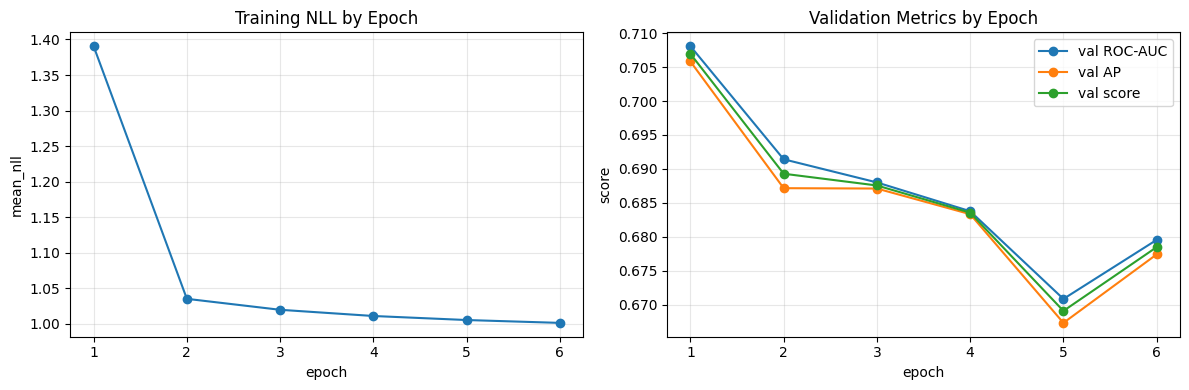

Final model checkpoint: /content/drive/MyDrive/facialgen_checkpoints/coraml_t4_run/final


In [11]:
history_df = pd.DataFrame(history)
display(history_df)
if not history_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df['epoch'], history_df['mean_nll'], marker='o', label='train NLL')
    axes[0].set_title('Training NLL by Epoch')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('mean_nll')
    axes[0].grid(True, alpha=0.3)
    if 'val_roc_auc' in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df['val_roc_auc'], marker='o', label='val ROC-AUC')
    if 'val_ap' in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df['val_ap'], marker='o', label='val AP')
    if 'val_score' in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df['val_score'], marker='o', label='val score')
    axes[1].set_title('Validation Metrics by Epoch')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('score')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

print('Final model checkpoint:', Path(args.save_dir) / 'final' if args.save_dir else 'not saved')


## Sample Inspection

Load a saved checkpoint and inspect a few generated sequences directly.


In [12]:
checkpoint_root = Path(args.save_dir) if args.save_dir else None
latest_epoch_dir = None
if checkpoint_root is not None and checkpoint_root.exists():
    epoch_dirs = sorted(checkpoint_root.glob('epoch_*'))
    if epoch_dirs:
        latest_epoch_dir = epoch_dirs[-1]

inspect_checkpoint_dir = (
    Path(checkpoint_dir)
    if checkpoint_dir is not None
    else (Path(args.save_dir) / 'final' if args.save_dir and (Path(args.save_dir) / 'final').exists() else latest_epoch_dir)
)
inspect_num_samples = 5
inspect_max_length = args.vertex_context_size

if inspect_checkpoint_dir is None:
    raise RuntimeError('No checkpoint directory is available to inspect.')

print('inspect_checkpoint_dir =', inspect_checkpoint_dir)
inspect_model = FacialGen.from_pretrained(str(inspect_checkpoint_dir))
inspect_model.to(device)
inspect_walks = sample_model_walks(
    inspect_model,
    num_samples=inspect_num_samples,
    max_length=inspect_max_length,
    bos_token_id=int(eval_info['bos_token_id']),
    eos_token_id=int(eval_info['eos_token_id']) if eval_info['eos_token_id'] is not None else None,
    device=device,
    batch_size=inspect_num_samples,
    show_progress=False,
)

rows = []
for idx, seq in enumerate(inspect_walks):
    special_tokens = {int(eval_info['bos_token_id'])}
    if eval_info['eos_token_id'] is not None:
        special_tokens.add(int(eval_info['eos_token_id']))
    stripped = [tok for tok in seq if tok not in special_tokens]
    rows.append({
        'sample_id': idx,
        'raw_tokens': seq,
        'vertex_tokens': stripped,
        'length_with_specials': len(seq),
        'vertex_length': len(stripped),
    })

display(pd.DataFrame(rows))


inspect_checkpoint_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_t4_run/final


Loading weights:   0%|          | 0/16 [00:00<?, ?it/s]

,sample_id,raw_tokens,vertex_tokens,length_with_specials,vertex_length
0,0,"[2810, 1063, 1105, 1150, 1063, 1211, 1150, 270...","[1063, 1105, 1150, 1063, 1211, 1150, 2700, 121...",16,14
1,1,"[2810, 565, 2071, 611, 565, 1792, 611, 729, 17...","[565, 2071, 611, 565, 1792, 611, 729, 1792, 24...",16,14
2,2,"[2810, 1422, 2133, 1861, 1422, 2573, 1861, 222...","[1422, 2133, 1861, 1422, 2573, 1861, 2227, 257...",16,14
3,3,"[2810, 2259, 339, 2525, 2259, 234, 2525, 2621,...","[2259, 339, 2525, 2259, 234, 2525, 2621, 234, ...",16,14
4,4,"[2810, 2100, 2118, 1168, 2100, 907, 1168, 2274...","[2100, 2118, 1168, 2100, 907, 1168, 2274, 907,...",16,14


## Final Evaluation

Generate walks from the trained model, reconstruct a graph, and compare link prediction and graph statistics against the true CoraML LCC.


In [13]:
reference_adj = eval_info['reference_adj']
reference_labels = eval_info['reference_labels']
num_nodes = int(eval_info['num_nodes'])
num_reference_edges = int(eval_info['num_reference_edges'])
lp_split = eval_info['link_prediction_split']
if lp_split is None:
    lp_split = connected_link_prediction_split(
        reference_adj,
        val_fraction=args.val_fraction,
        test_fraction=args.test_fraction,
        seed=args.split_seed,
    )

reference_stats = compute_graph_statistics(reference_adj, labels=reference_labels)

generated_results = []
generated_stats_rows = []

for graph_idx in range(num_generated_graphs):
    walks = sample_model_walks(
        model,
        num_samples=final_generated_walks,
        max_length=final_max_length,
        bos_token_id=int(eval_info['bos_token_id']),
        eos_token_id=int(eval_info['eos_token_id']) if eval_info['eos_token_id'] is not None else None,
        device=device,
        batch_size=generation_batch_size,
        show_progress=True,
        progress_desc=f'final sampling graph {graph_idx + 1}/{num_generated_graphs}',
    )

    A_hat, S = reconstruct_graph_from_generated_walks(
        walks,
        num_nodes=num_nodes,
        target_num_edges=num_reference_edges,
        seed=reconstruction_seed + graph_idx,
    )

    val_scores = link_prediction_scores_from_walks(
        walks,
        num_nodes=num_nodes,
        positive_edges=lp_split['val_edges'],
        negative_edges=lp_split['val_non_edges'],
    )
    test_scores = link_prediction_scores_from_walks(
        walks,
        num_nodes=num_nodes,
        positive_edges=lp_split['test_edges'],
        negative_edges=lp_split['test_non_edges'],
    )
    graph_stats = compute_graph_statistics(A_hat, labels=reference_labels)
    overlap = edge_overlap_ratio(A_hat, reference_adj)

    generated_results.append({
        'graph_id': graph_idx,
        'val_roc_auc': float(val_scores['roc_auc']),
        'val_ap': float(val_scores['average_precision']),
        'test_roc_auc': float(test_scores['roc_auc']),
        'test_ap': float(test_scores['average_precision']),
        'edge_overlap': float(overlap),
    })
    generated_stats_rows.append(graph_stats)

lp_table = pd.DataFrame(generated_results)
display(lp_table)

metric_names = list(reference_stats.keys())
stats_table = pd.DataFrame([
    {
        'metric': metric,
        'true_coraml': float(reference_stats[metric]),
        'generated_mean': float(np.nanmean([row[metric] for row in generated_stats_rows])),
        'abs_diff': abs(
            float(np.nanmean([row[metric] for row in generated_stats_rows]))
            - float(reference_stats[metric])
        ),
    }
    for metric in metric_names
])
display(stats_table)

if history:
    display(pd.DataFrame(history))


final sampling graph 1/1:   0%|          | 0/1954 [00:00<?, ?it/s]

,graph_id,val_roc_auc,val_ap,test_roc_auc,test_ap,edge_overlap
0,0,0.761148,0.758409,0.757718,0.753803,0.431901


,metric,true_coraml,generated_mean,abs_diff
0,max_degree,246.000000,275.000000,29.000000
1,assortativity,-0.076592,-0.051586,0.025006
2,triangle_count,5247.000000,3962.000000,1285.000000
3,power_law_exp,1.500883,1.498299,0.002585
4,clustering_coeff,0.114298,0.074173,0.040124
5,characteristic_path_len,5.271418,4.464937,0.806481
6,inter_community_density,0.000526,0.000829,0.000303
7,intra_community_density,0.009280,0.007808,0.001472


,epoch,mean_nll,perplexity,val_roc_auc,val_ap,val_score
0,1.0,1.390581,4.017185,0.708073,0.705817,0.706945
1,2.0,1.035297,2.815943,0.691425,0.687170,0.689297
2,3.0,1.019884,2.772872,0.688017,0.687118,0.687567
3,4.0,1.011162,2.748794,0.683782,0.683342,0.683562
4,5.0,1.005491,2.733250,0.670869,0.667342,0.669106
5,6.0,1.001471,2.722284,0.679565,0.677426,0.678495
